# Imports

In [ ]:
import numpy as np
import pandas as pd
import json
import datetime

import re
import nltk
from nltk.corpus import stopwords

from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn import datasets, linear_model
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Read Categories Json and Trending Data for US

In [ ]:
categories_df = pd.read_json('/content/drive/Shared drives/Google3F_AI_Studio/US_category_id.json')
categories_df = pd.json_normalize(categories_df['items'])[['id', 'snippet.title']]
categories_df = categories_df.rename(columns={'snippet.title': 'title'})

In [ ]:
data_df = pd.read_csv('/content/drive/Shared drives/Google3F_AI_Studio/US_youtube_trending_data.csv')
data_df['publishedAt'] = pd.to_datetime(data_df['publishedAt'], dayfirst=True, format='ISO8601', utc=True)
data_df['trending_date'] = pd.to_datetime(data_df['trending_date'], dayfirst=True, format='ISO8601', utc=True)

# Add a day of the week column
data_df.loc[:, 'published_day_of_week'] = data_df['publishedAt'].dt.day_name()

Merge the categories_df into the data_df to add a CategoryName to go with the categoryId so it's more interpretable.

In [ ]:

# Convert 'categoryId' in data_df to string type so a join can be performed
data_df['categoryId'] = data_df['categoryId'].astype(str)
data_df = pd.merge(data_df, categories_df, left_on='categoryId', right_on='id', how='left')
data_df = data_df.rename(columns={'title_x': 'title', 'title_y': 'categoryName'})
# Rearrange columns to place 'categoryName' after 'categoryId'
data_df = data_df[['video_id','title', 'publishedAt', 'published_day_of_week', 'channelId', 'channelTitle',
                   'categoryId', 'categoryName', 'trending_date', 'tags', 'view_count',
                   'likes', 'dislikes', 'comment_count','description']]

In [ ]:


unique_counts = data_df.nunique()
unique_counts_table = pd.DataFrame({'Column': unique_counts.index, 'Unique Values': unique_counts.values})
print(unique_counts_table)


                   Column  Unique Values
0                video_id          47142
1                   title          48471
2             publishedAt          46554
3   published_day_of_week              7
4               channelId           8302
5            channelTitle           8543
6              categoryId             15
7            categoryName             15
8           trending_date           1323
9                    tags          32909
10             view_count         255236
11                  likes         136839
12               dislikes          13179
13          comment_count          35557
14            description          48448


In [ ]:
print(data_df.shape)
# print("2020:",df_2020.shape)
# print("2021:",df_2021.shape)
# print("2022:",df_2022.shape)
# print("2023:",df_2023.shape)
# print("2024:",df_2024.shape)

(268787, 15)


In [ ]:
data_df.columns

Index(['video_id', 'title', 'publishedAt', 'published_day_of_week',
       'channelId', 'channelTitle', 'categoryId', 'categoryName',
       'trending_date', 'tags', 'view_count', 'likes', 'dislikes',
       'comment_count', 'description'],
      dtype='object')

In [ ]:
categories_df = pd.read_json('/content/drive/Shared drives/Google3F_AI_Studio/US_category_id.json')
categories_df = pd.json_normalize(categories_df['items'])[['id', 'snippet.title']]
categories_df = categories_df.rename(columns={'snippet.title': 'title'})

data_df = pd.read_csv('/content/drive/Shared drives/Google3F_AI_Studio/US_youtube_trending_data.csv')
data_df['publishedAt'] = pd.to_datetime(data_df['publishedAt'], dayfirst=True, format='ISO8601', utc=True)
data_df['trending_date'] = pd.to_datetime(data_df['trending_date'], dayfirst=True, format='ISO8601', utc=True)

# Add a day of the week column
data_df.loc[:, 'published_day_of_week'] = data_df['publishedAt'].dt.day_name()

import pandas as pd
# Convert 'categoryId' in data_df to string type so a join can be performed
data_df['categoryId'] = data_df['categoryId'].astype(str)
data_df = pd.merge(data_df, categories_df, left_on='categoryId', right_on='id', how='left')
data_df = data_df.rename(columns={'title_x': 'title', 'title_y': 'categoryName'})


#features



In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# data_df['days_since_published'] = (data_df['trending_date'] - data_df['publishedAt']).dt.days

# # Ensure days_since_published is at least 1
# data_df['days_since_published'] = data_df['days_since_published'].clip(lower=1)

# # Add the new features
# data_df['square_days_since_published'] = data_df['days_since_published'] ** 2
# data_df['sqrt_days_since_published'] = np.sqrt(data_df['days_since_published'])
# data_df['log_days_since_published'] = np.log(data_df['days_since_published'])

# # Create a list of features to scale
# features_to_scale = ['days_since_published', 'square_days_since_published',
#                      'sqrt_days_since_published', 'log_days_since_published']

# # Initialize the MinMaxScaler
# scaler = MinMaxScaler()

# # Fit the scaler and transform the features
# data_df[features_to_scale] = scaler.fit_transform(data_df[features_to_scale])

# # Display the first few rows of the scaled features
# print(data_df[features_to_scale].head())


In [ ]:


# Count the occurrences of each channel
channel_counts = data_df['channelTitle'].value_counts()

# Get the top 100 channels
top_100_channels = channel_counts.head(100).index.tolist()

# Create a new column with one-hot encoded channels
for channel in top_100_channels:
  data_df[f'channel_{channel}'] = (data_df['channelTitle'] == channel).astype(int)

# Now your data_df has 100 new columns, each representing a top channel,
# with a value of 1 if the video is from that channel, 0 otherwise.

<ipython-input-73-ab863700ef2c>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[f'channel_{channel}'] = (data_df['channelTitle'] == channel).astype(int)
<ipython-input-73-ab863700ef2c>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[f'channel_{channel}'] = (data_df['channelTitle'] == channel).astype(int)
<ipython-input-73-ab863700ef2c>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

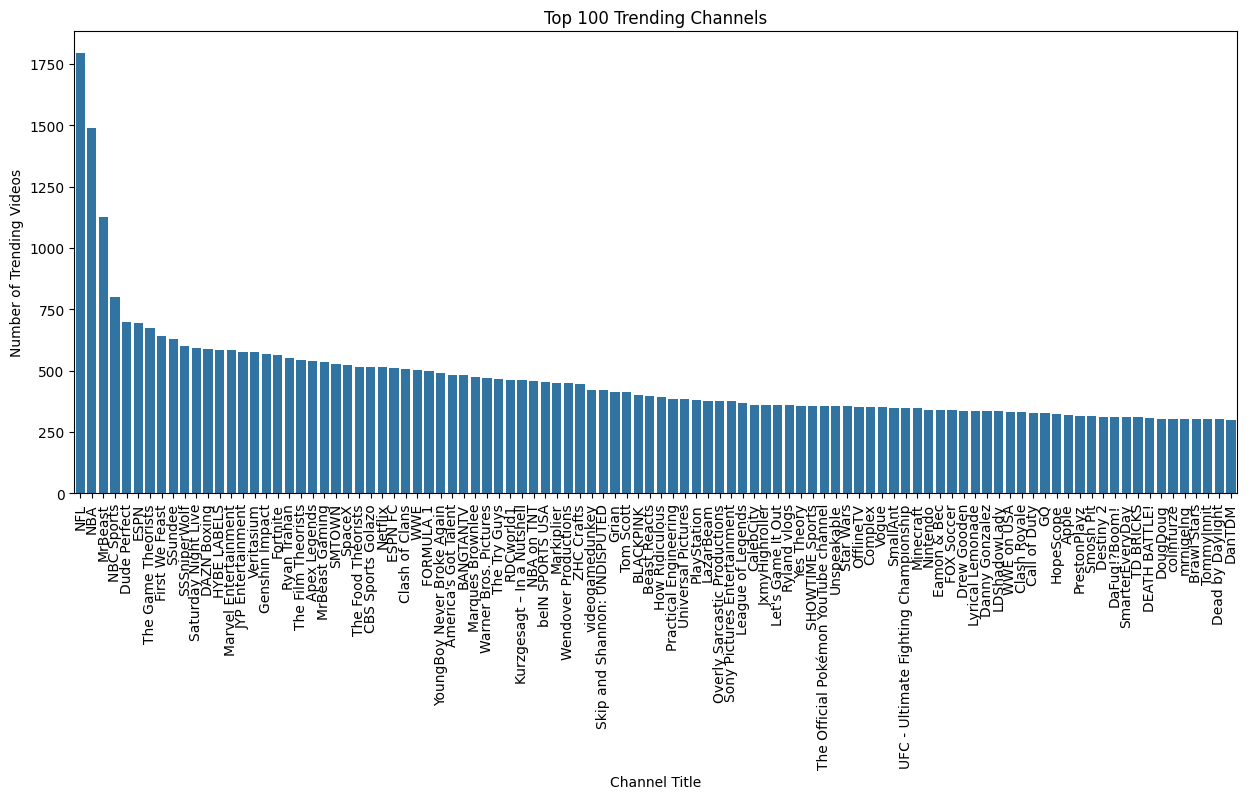

In [ ]:


# Get the top 100 channels and their counts
top_100_channels = data_df['channelTitle'].value_counts().head(100)

# Create a bar plot of the top 100 channels
plt.figure(figsize=(15, 6))
sns.barplot(x=top_100_channels.index, y=top_100_channels.values)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Set labels and title
plt.xlabel('Channel Title')
plt.ylabel('Number of Trending Videos')
plt.title('Top 100 Trending Channels')

# Show the plot
plt.show()

In [ ]:


# Assuming 'data_df' is your DataFrame and 'categoryName' is the column with categories.

# Get the top 15 categories
top_15_categories = data_df['categoryName'].value_counts().nlargest(15).index.tolist()

# Create a new column with one-hot encoded categories
for category in top_15_categories:
  data_df[f'category_{category}'] = (data_df['categoryName'] == category).astype(int)

# Now your data_df has 15 new columns, each representing a top category,
# with a value of 1 if the video belongs to that category, 0 otherwise.

<ipython-input-75-61d707093915>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[f'category_{category}'] = (data_df['categoryName'] == category).astype(int)
<ipython-input-75-61d707093915>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df[f'category_{category}'] = (data_df['categoryName'] == category).astype(int)
<ipython-input-75-61d707093915>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining al

In [ ]:
list(data_df.columns)


['video_id',
 'title',
 'publishedAt',
 'channelId',
 'channelTitle',
 'categoryId',
 'trending_date',
 'tags',
 'view_count',
 'likes',
 'dislikes',
 'comment_count',
 'thumbnail_link',
 'comments_disabled',
 'ratings_disabled',
 'description',
 'published_day_of_week',
 'id',
 'categoryName',
 'channel_NFL',
 'channel_NBA',
 'channel_MrBeast',
 'channel_NBC Sports',
 'channel_Dude Perfect',
 'channel_ESPN',
 'channel_The Game Theorists',
 'channel_First We Feast',
 'channel_SSundee',
 'channel_SSSniperWolf',
 'channel_Saturday Night Live',
 'channel_DAZN Boxing',
 'channel_HYBE LABELS',
 'channel_Marvel Entertainment',
 'channel_JYP Entertainment',
 'channel_Veritasium',
 'channel_Genshin Impact',
 'channel_Fortnite',
 'channel_Ryan Trahan',
 'channel_The Film Theorists',
 'channel_Apex Legends',
 'channel_MrBeast Gaming',
 'channel_SMTOWN',
 'channel_SpaceX',
 'channel_The Food Theorists',
 'channel_CBS Sports Golazo',
 'channel_Netflix',
 'channel_ESPN FC',
 'channel_Clash of Clans

# Label

In [ ]:


# Create a OneHotEncoder object
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Reshape the data before encoding
encoded_data = encoder.fit_transform(data_df[['published_day_of_week']])

# Create a DataFrame from the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['published_day_of_week']))

# Concatenate the encoded DataFrame with the original DataFrame
data_df = pd.concat([data_df, encoded_df], axis=1)




In [ ]:
# Calculate the difference between trending_date and publishedAt in days
data_df['days_since_published'] = (data_df['trending_date'] - data_df['publishedAt']).dt.days +2



data_df['log_view_velocity'] = np.log(data_df['view_count'] +1) / data_df['days_since_published']
data_df['view_velocity'] = data_df['view_count']+1 / data_df['days_since_published']

data_df['log_days_since_published'] = np.log(data_df['days_since_published'])
data_df['square_days_since_published'] = data_df['days_since_published'] ** 2
data_df['sqrt_days_since_published'] = np.sqrt(data_df['days_since_published'])


# Calculate the mean of the 'view_velocity' column (or whichever column you want to use)
mean = data_df['view_velocity'].mean()

# Fill NaN values in 'data_df' with the calculated mean
data_df.fillna(value=mean, inplace=True)


In [ ]:
data_df['log_view_velocity'].describe()

,log_view_velocity
count,268787.000000
mean,3.298111
std,1.651311
min,0.000000
25%,2.154144
50%,2.785231
75%,4.125472
max,18.021870


#Decision Tree Model


In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Define your features and target variable
features = ['days_since_published', 'square_days_since_published', 'sqrt_days_since_published', 'log_days_since_published']
top_100_channels_features = [col for col in data_df.columns if col.startswith('channel_')]
top_15_categories_features = [col for col in data_df.columns if col.startswith('category_')]
day_of_week_features = [col for col in data_df.columns if col.startswith('published_day_of_week_')]
features.extend(top_100_channels_features)
features.extend(top_15_categories_features)
features.extend(day_of_week_features)

target = 'log_view_velocity'

# Select the features and target variable from your DataFrame
X = data_df[features]
y = data_df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse}")


RMSE: 0.2548521355331197


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
import pandas as pd

# Split data into train, validation, and test sets based on dates
train_data = data_df[data_df['trending_date'].dt.year == 2023]
val_data = data_df[(data_df['trending_date'].dt.year == 2024) & (data_df['trending_date'] <= pd.to_datetime('2024-02-18', utc=True))] # Make the Timestamp timezone-aware
test_data = data_df[(data_df['trending_date'].dt.year == 2024) & (data_df['trending_date'] >= pd.to_datetime('2024-02-18', utc=True))] # Make the Timestamp timezone-aware

# Define your features and target variable
features = ['days_since_published', 'square_days_since_published', 'sqrt_days_since_published', 'log_days_since_published']
top_100_channels_features = [col for col in data_df.columns if col.startswith('channel_')]
top_15_categories_features = [col for col in data_df.columns if col.startswith('category_')]
day_of_week_features = [col for col in data_df.columns if col.startswith('published_day_of_week_')]
features.extend(top_100_channels_features)
features.extend(top_15_categories_features)
features.extend(day_of_week_features)

target = 'log_view_velocity'

# Select the features and target variable from your DataFrame
X_train = train_data[features]
y_train = train_data[target]
X_val = val_data[features]
y_val = val_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Now you have X_train, y_train, X_val, y_val, X_test, y_test ready for model training and evaluation.


In [ ]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Assuming you have X_train, y_train, X_val, y_val, X_test, y_test defined as in your previous code

# Create a Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Evaluate the model on the validation set
rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
print(f"Validation RMSE: {rmse_val}")

# Make predictions on the test set
y_test_pred = model.predict(X_test)

# Evaluate the model on the test set
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
print(f"Test RMSE: {rmse_test}")


Validation RMSE: 0.22452473934673267
Test RMSE: 0.2145571654781371


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:


y_train_pred = model.predict(X_train)
rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
print(f"Training RMSE: {rmse_train}")

Training RMSE: 0.2249143644840846


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:


# Assuming you have X_train, y_train, X_val, y_val, X_test, y_test defined as in your previous code

# Create a Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Evaluate the model on the validation set
mse_val = mean_squared_error(y_val, y_val_pred)
print(f"Validation MSE: {mse_val}")

# Make predictions on the test set
y_test_pred = model.predict(X_test)

# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test}")

Validation MSE: 0.05041135857871825
Test MSE: 0.04603477725801271


In [ ]:


print(f"Training RMSE: {mean_squared_error(y_train, model.predict(X_train), squared=False)}")

Training RMSE: 0.2249143644840846


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


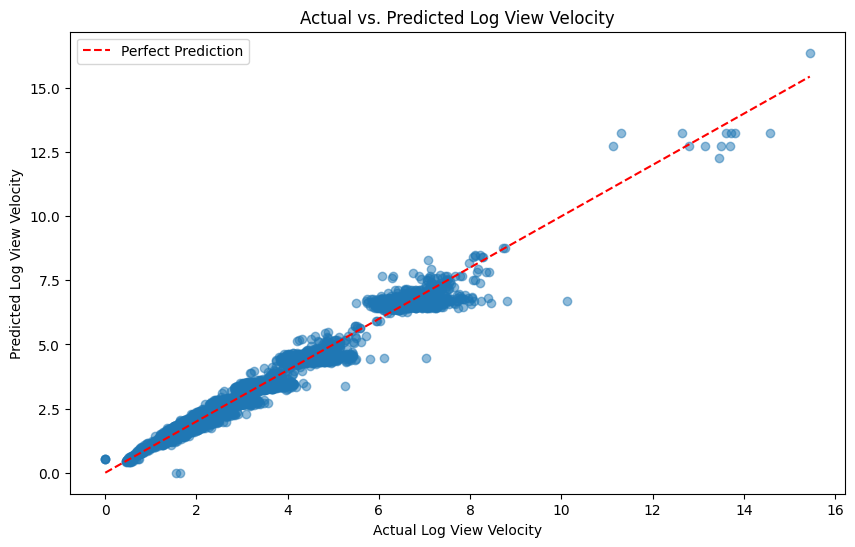

In [ ]:


# Assuming y_test and y_test_pred are your actual and predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Log View Velocity")
plt.ylabel("Predicted Log View Velocity")
plt.title("Actual vs. Predicted Log View Velocity")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='Perfect Prediction')
plt.legend()
plt.show()

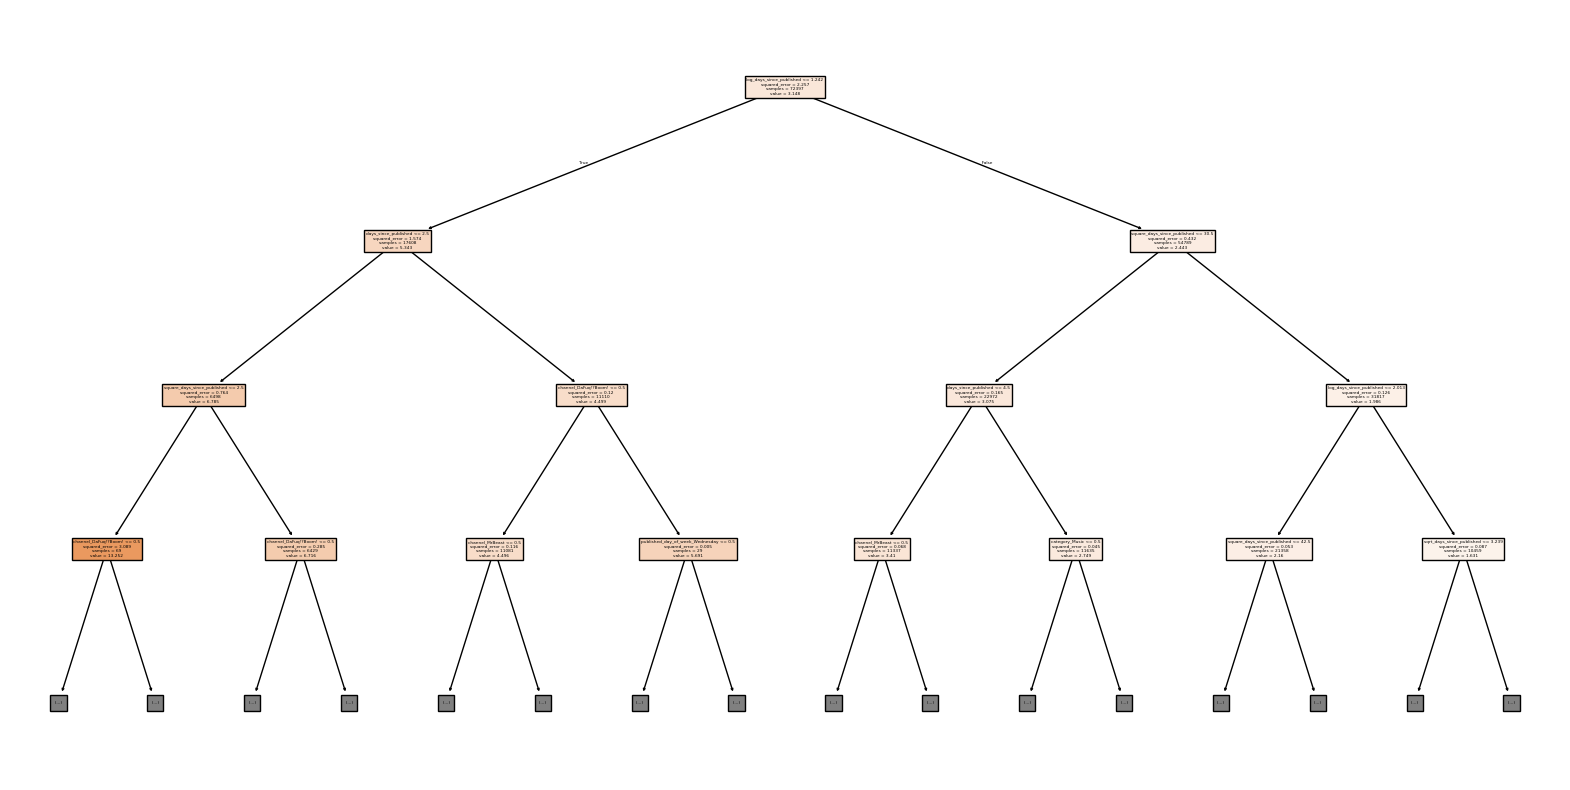

In [ ]:
# prompt: create graph of the nodes of the decision tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Adjust figure size as needed
plot_tree(model, feature_names=features, filled=True, max_depth=3)  # You can adjust max_depth for visualization
plt.show()

In [ ]:
# prompt: run a grid search

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print("Best Parameters:", grid_search.best_params_)

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model on the validation set
y_val_pred = best_model.predict(X_val)
rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
print(f"Validation RMSE with Best Model: {rmse_val}")

# Evaluate the best model on the test set
y_test_pred = best_model.predict(X_test)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
print(f"Test RMSE with Best Model: {rmse_test}")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Validation RMSE with Best Model: 0.22114706156480463
Test RMSE with Best Model: 0.21139697707802918


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# prompt: get train rmse result

print(f"Test RMSE: {rmse_test}")

Test RMSE: 0.21139697707802918


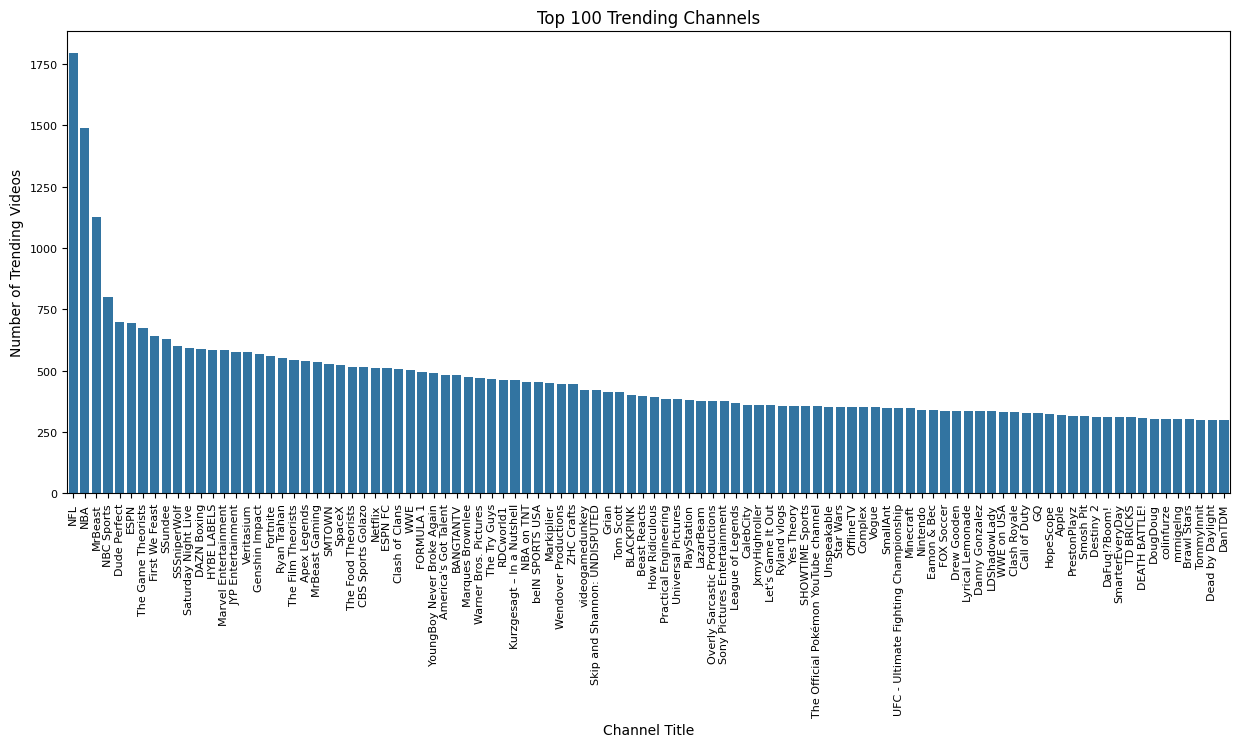

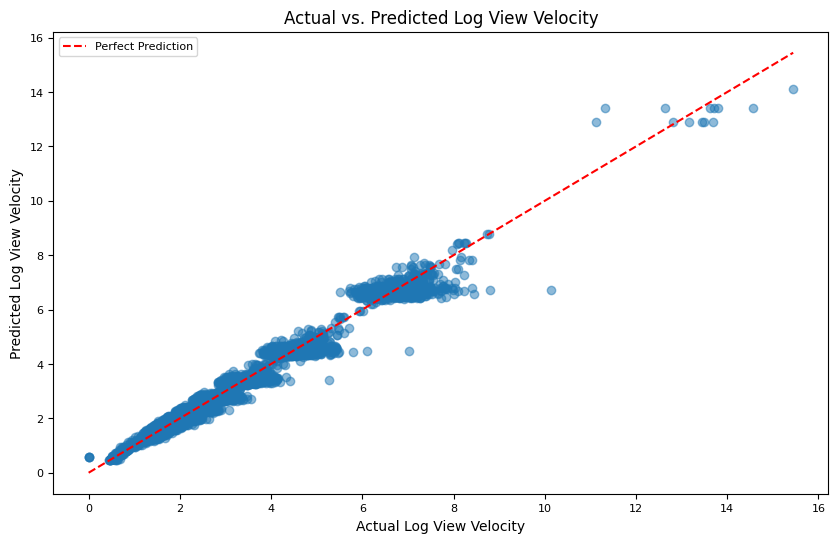

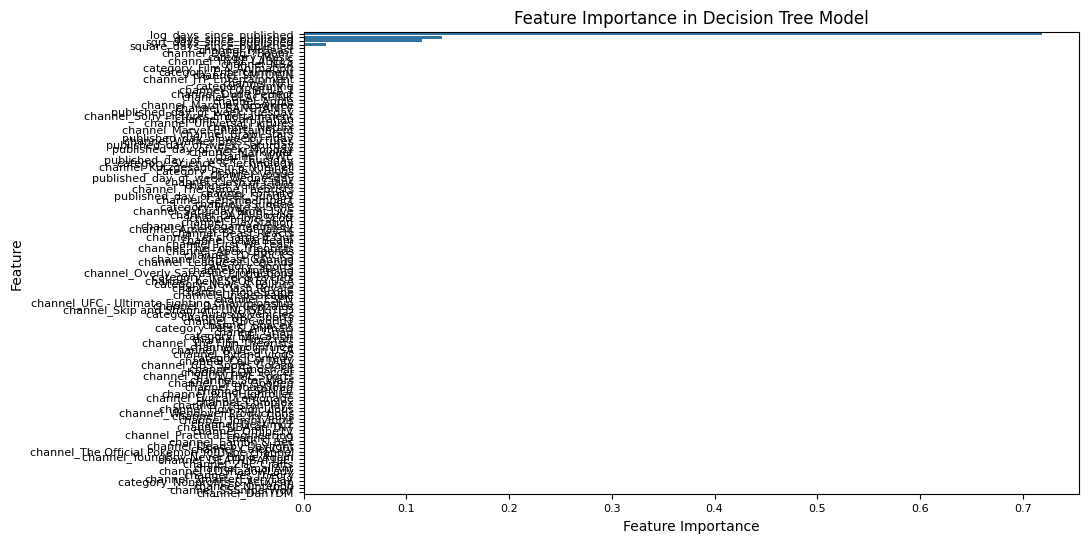

In [ ]:

plt.figure(figsize=(15, 6))
sns.barplot(x=top_100_channels.index, y=top_100_channels.values)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=8)  # Adjust fontsize as needed
plt.yticks(fontsize=8)  # Adjust fontsize as needed

# Set labels and title
plt.xlabel('Channel Title', fontsize=10)
plt.ylabel('Number of Trending Videos', fontsize=10)
plt.title('Top 100 Trending Channels', fontsize=12)

# Show the plot
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Log View Velocity", fontsize=10)
plt.ylabel("Predicted Log View Velocity", fontsize=10)
plt.title("Actual vs. Predicted Log View Velocity", fontsize=12)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', label='Perfect Prediction')
plt.legend(fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()



plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.title('Feature Importance in Decision Tree Model', fontsize=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

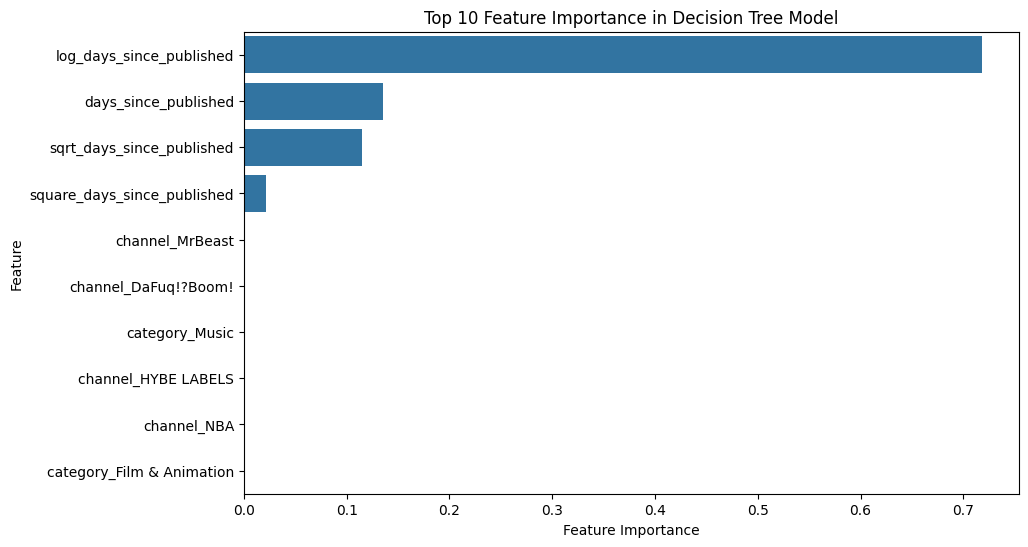

In [ ]:


# Assuming feature_importance_df is already defined as in your previous code
top_10_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance in Decision Tree Model')
plt.show()